<a href="https://colab.research.google.com/github/sirimadhuri02/Machine_Learning/blob/ML_course/ml5_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

data = pd.read_excel('knn_classification_data.xlsx')

numeric_columns = ['Pages_visited', 'Time_spent', 'Items_viewed']
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())


data['Purchased'] = data['Purchased'].map({'Yes': 1, 'No': 0})

X = data[['Pages_visited', 'Time_spent', 'Items_viewed']].values
y = data['Purchased'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with k=3: {accuracy:.2f}')



Accuracy with k=3: 0.50


In [ ]:

def plot_decision_boundaries(X, y, k):

    X_plot = X[:, :2]


    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])


    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))


    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_plot, y)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.title(f"k-NN decision boundary with k={k}")
    plt.xlabel('Pages_visited')
    plt.ylabel('Time_spent')
    plt.show()



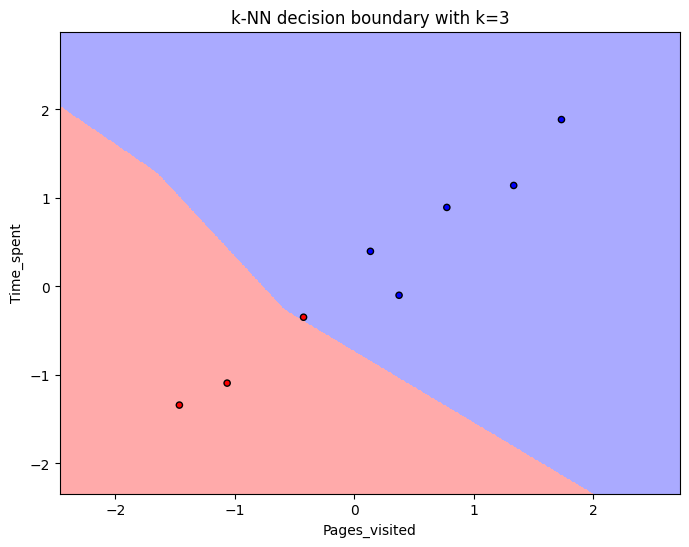

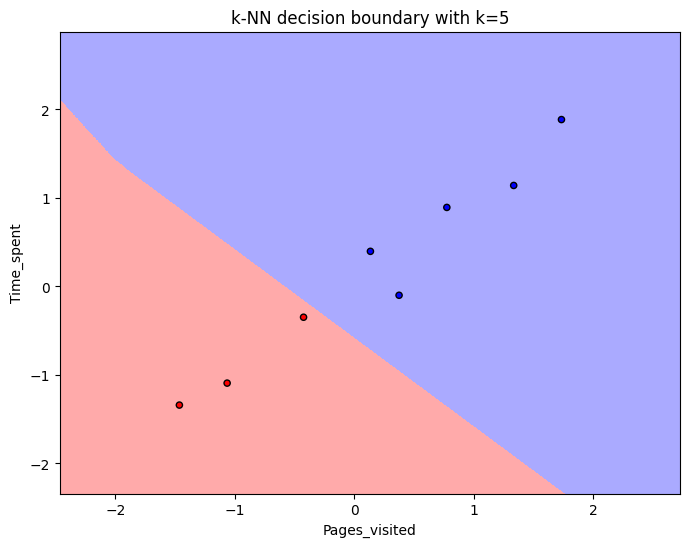

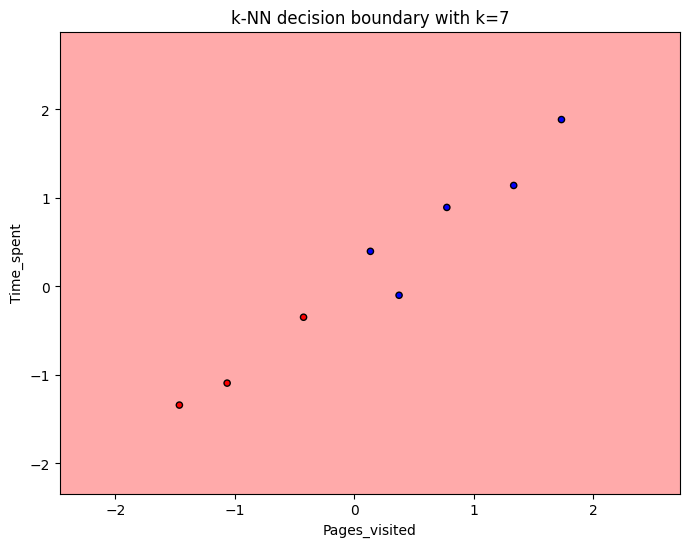

In [ ]:

for k in [3, 5, 7]:
    plot_decision_boundaries(X_train, y_train, k)


In [ ]:

for k in [5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy with k={k}: {accuracy:.2f}')

Accuracy with k=5: 0.50
Accuracy with k=7: 0.50
